In [1]:
!pip -q install -U ultralytics onnx onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 81.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 77.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from pathlib import Path
from collections import Counter

import json
import random
import shutil
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import Video, display
from matplotlib.patches import Rectangle
from PIL import Image
from ultralytics import YOLO
from concurrent.futures import ThreadPoolExecutor

In [5]:
DRIVE_DATASET_ROOT = Path("/content/drive/MyDrive/Yolo_road2022_dataset/RDD2022_China_MotorBike")
DATASET_ROOT  = Path("/content/RDD2022_China_MotorBike_1")


def copy_file(src_file, src_root, dst_root):
    relative_path = src_file.relative_to(src_root)
    dest_file = dst_root / relative_path
    dest_file.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src_file, dest_file)


for split in ["train", "val"]:
    src_dir = DRIVE_DATASET_ROOT / split
    dst_dir = DATASET_ROOT / split
    files = [p for p in src_dir.rglob("*") if p.is_file()]
    with ThreadPoolExecutor(max_workers=16) as executor:
        futures = [
            executor.submit(copy_file, f, src_dir, dst_dir) for f in files
        ]
        for future in futures:
            future.result()

In [9]:
BEST_MODEL_PATH = Path(
    DRIVE_DATASET_ROOT /
    "runs/yolo26n_rdd2022_baseline" /
    "weights/best.pt"
)

DATA_YAML_PATH = Path(
    DRIVE_DATASET_ROOT / "configs" /
    "rdd2022_china_motorbike.yaml"
)

DATASET_ROOT = Path(
    "/content/"
    "RDD2022_China_MotorBike_1"
)

VAL_IMAGES_DIR = DATASET_ROOT / "val" / "images"
VAL_LABELS_DIR = DATASET_ROOT / "val" / "labels"

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/"
    "Yolo_road2022_dataset/"
    "unit_01_final_analysis"
)

required_paths = [BEST_MODEL_PATH, DATA_YAML_PATH, VAL_IMAGES_DIR, VAL_LABELS_DIR]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Path not found:\n{path}")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("Best model :", BEST_MODEL_PATH)
print("Validation :", VAL_IMAGES_DIR)
print("Output     :", OUTPUT_ROOT)

Best model : /content/drive/MyDrive/Yolo_road2022_dataset/RDD2022_China_MotorBike/runs/yolo26n_rdd2022_baseline/weights/best.pt
Validation : /content/RDD2022_China_MotorBike_1/val/images
Output     : /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis


**Load model and device**

In [10]:
DEVICE = (0 if torch.cuda.is_available() else "cpu")
model = YOLO(str(BEST_MODEL_PATH))

print("Device:", DEVICE)
print("Classes:")
for class_id, class_name in model.names.items():
    print(class_id, "→", class_name)

Device: 0
Classes:
0 → D00
1 → D10
2 → D20
3 → D40


In [11]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp"}

val_images = sorted(
    path
    for path in VAL_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_SUFFIXES
)

labels_by_stem = {
    path.stem: path for path in VAL_LABELS_DIR.glob("*.txt")
}

images_by_stem = {
    path.stem: path for path in val_images
}

print("Validation images:", len(val_images))

Validation images: 387


### Systematic Error Analysis

**YOLO label → absolute XYXY**

In [12]:
def load_ground_truth(label_path, image_width, image_height):
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return {
            "boxes" : np.empty((0, 4), dtype=np.float32),
            "classes" : np.empty((0), dtype=np.float64)
        }
    
    boxes = []
    classes = []
    
    for line in text.splitlines():
        parts = line.split()
        class_id = int(parts[0])
        
        center_x = float(parts[1])
        center_y = float(parts[2])
        box_width = float(parts[3])
        box_height = float(parts[4])
        
        center_x *= image_width
        center_y *= image_height
        box_width *= image_width
        box_height *= image_height
        
        x1 = center_x - box_width / 2
        y1 = center_y - box_height / 2
        x2 = center_x + box_width / 2
        y2 = center_y + box_height / 2
        
        boxes.append([x1, y1, x2, y2])
        classes.append(class_id)
        
        return {
            "boxes": np.asarray(boxes, dtype=np.float32),
            "classes": np.asarray(classes,dtype=np.int64)
        }

**NumPy IoU**

In [13]:
def calculate_ious(box, candidate_boxes):
    if len(candidate_boxes) == 0:
        return np.empty((0,), dtype=np.float32)
    
    interse_x1 = np.maximum(box[0], candidate_boxes[:, 0])
    interse_y1 = np.maximum(box[1], candidate_boxes[:, 1])
    interse_x2 = np.maximum(box[2], candidate_boxes[:, 2])
    interse_y2 = np.maximum(box[3], candidate_boxes[:, 3])
    
    interse_width = np.maximum(0, interse_x2 - interse_x1)
    interse_height = np.maximum(0, interse_y2 - interse_y1)
    
    inter_area = interse_width * interse_height
    box_area = (max(0, box[2] - box[0]) * max(0, box[3] - box[1]))
    
    candidate_area = (
        np.maximum(0, candidate_boxes[:, 2] - candidate_boxes[:, 0]) * np.maximum(0, candidate_boxes[:, 3] - candidate_boxes[:, 1])
    )
    
    union_area = box_area + candidate_area - inter_area
    
    return np.divide(
        inter_area, union_area,
        out=np.zeros_like(inter_area),
        where=union_area > 0
    )

**Cache validation predictions**

In [14]:
MINIMUM_ANALYSIS_CONFIDENCE = 0.01
IMAGE_SIZE = 640
prediction_cache = []

result_generator = model.predict(
    source=str(VAL_IMAGES_DIR),
    imgsz=IMAGE_SIZE,
    conf=MINIMUM_ANALYSIS_CONFIDENCE,
    device=DEVICE,
    stream=True,
    save=False,
    verbose=False
)

In [15]:
for result in result_generator:
    image_path = Path(result.path)
    image_height, image_width = result.orig_shape
    
    ground_truth = load_ground_truth(
        labels_by_stem[image_path.stem],
        image_width, image_height
    )
    
    prediction_cache.append({
        "stem" : image_path.stem,
        "image_path" : image_path,
        "image_width": image_width,
        "image_height": image_height,
        "gt_boxes" : ground_truth["boxes"],
        "gt_classes" : ground_truth["classes"],
        "pred_boxes" : (
            result.boxes.xyxy.detach().cpu().numpy().astype(np.float32)
        ),
        "pred_classes" : (
            result.boxes.cls.detach().cpu().numpy().astype(np.float32)
        ),
        "pred_confidences" : (
            result.boxes.conf.detach().cpu().numpy().astype(np.float32)
        )
    })


print("Cached images:", len(prediction_cache))

Cached images: 387


**One-to-one matching**

In [25]:
def match_image(item, confidence_threshold, iou_threshold=0.50):
    gt_boxes = item["gt_boxes"]
    gt_classes = item["gt_classes"]
    keep = item["pred_confidences"] >= confidence_threshold
    
    pred_boxes = item["pred_boxes"][keep]
    pred_classes = item["pred_classes"][keep]
    pred_confidences = item["pred_confidences"][keep]
    order = np.argsort(-pred_confidences)
    
    pred_boxes = pred_boxes[order]
    pred_classes = pred_classes[order]
    pred_confidences = pred_confidences[order]

    match_ground_truths = set()
    prediction_datails = []
    
    class_statistics = {
        int(class_id): {"tp": 0, "fp": 0, "fn": 0} for class_id in model.names
    }
    
    for pred_box, pred_class, confidence in zip(
        pred_boxes, pred_classes, pred_confidences
    ):
        candidate_indices = [
            index for index, gt_class in enumerate(gt_classes)
            if (int(gt_class) == int(pred_class) and index not in match_ground_truths)
        ]
        
        matched_index = None
        matched_iou = 0.0
        
        if candidate_indices:
            candidate_boxes = gt_boxes[candidate_indices]
            candidate_ious = calculate_ious(pred_box, candidate_boxes)
            
            best_local_index = int(np.argmax(candidate_ious))
            matched_iou = float(candidate_ious[best_local_index])
            
            if matched_iou >= iou_threshold:
                matched_index = candidate_indices[best_local_index]
        
        if matched_index is not None:
            match_ground_truths.add(matched_index)
            class_statistics[int(pred_class)]["tp"] += 1
            
            prediction_datails.append({
                "box": pred_box,
                "class_id": int(pred_class),
                "confidence": float(confidence),
                "status": "TP",
                "reason": "correct",
                "iou": matched_iou,
            })
            continue
        
        class_statistics[int(pred_class)]["fp"] += 1
        all_ious = calculate_ious(pred_box, gt_boxes)
        
        if len(all_ious) == 0:
            best_any_iou = 0.0
            reason = "background_fp"
        else:
            best_gt_index = int(np.argmax(all_ious))
            best_any_iou = float(all_ious[best_gt_index])
            best_gt_class = int(gt_classes[best_gt_index])

            if (
                best_any_iou >= iou_threshold
                and best_gt_class != int(pred_class)
            ):
                reason = "wrong_class"
            elif (
                best_any_iou >= iou_threshold
                and best_gt_index in match_ground_truths
            ):
                reason = "duplicate"
            elif best_any_iou >= 0.10:
                reason = "poor_localization"
            else:
                reason = "background_fp"
                
        prediction_datails.append({
            "box": pred_box,
            "class_id": int(pred_class),
            "confidence": float(confidence),
            "status": "FP",
            "reason": reason,
            "iou": best_any_iou,
        })
        
    unmatched_ground_truths = []

    for gt_index, gt_class in enumerate(gt_classes):
        if gt_index not in match_ground_truths:
            class_statistics[int(gt_class)]["fn"] += 1
            unmatched_ground_truths.append(gt_index)

    total_tp = sum(
        values["tp"] for values in class_statistics.values()
    )
    total_fp = sum(
        values["fp"] for values in class_statistics.values()
    )
    total_fn = sum(
        values["fn"] for values in class_statistics.values()
    )
    
    return {
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "class_statistics": class_statistics,
        "prediction_details": prediction_datails,
        "matched_ground_truths": match_ground_truths,
        "unmatched_ground_truths": unmatched_ground_truths,
    }

**Evaluate a confidence threshold**

In [26]:
def safe_divide(numerator, denominator):
    return (numerator / denominator if denominator > 0 else 0.0)

def evaluate_threshold(confidence_threshold, iou_threshold=0.50):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    per_class = {
        class_id: {"tp": 0, "fp": 0, "fn": 0}
        for class_id in model.names
    }
    
    image_rows = []
    details_by_stem = {}
    for item in prediction_cache:
        matching = match_image(item, confidence_threshold,
            iou_threshold)
        
        total_tp += matching["tp"]
        total_fp += matching["fp"]
        total_fn += matching["fn"]
        
        for class_id in per_class:
            for metric_name in ["tp", "fp", "fn",]:
                per_class[class_id][metric_name] += matching[
                    "class_statistics"
                ][class_id][metric_name]

        image_rows.append({
            "stem": item["stem"],
            "tp": matching["tp"],
            "fp": matching["fp"],
            "fn": matching["fn"],
            "total_errors": (
                matching["fp"] + matching["fn"]
            ),
        })

        details_by_stem[item["stem"]] = matching
    
    precision = safe_divide(total_tp, total_tp + total_fp)
    recall = safe_divide(total_tp, total_tp + total_fn)
    f1_score = safe_divide(2 * precision * recall, precision + recall)

    return {
        "threshold": confidence_threshold,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": precision,
        "recall": recall,
        "f1": f1_score,
        "per_class": per_class,
        "image_rows": image_rows,
        "details_by_stem": (
            details_by_stem
        ),
    }

### Select Deployment Threshold

**Threshold sweep**

In [27]:
CONFIDENCE_THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]

threshold_rows = []

for threshold in CONFIDENCE_THRESHOLDS:
    evaluation = evaluate_threshold(confidence_threshold=threshold, iou_threshold=0.50)
    
    threshold_rows.append({
        "threshold": threshold,
        "tp": evaluation["tp"],
        "fp": evaluation["fp"],
        "fn": evaluation["fn"],
        "precision": evaluation["precision"],
        "recall": evaluation["recall"],
        "f1": evaluation["f1"],
    })
    

threshold_dataframe = pd.DataFrame(threshold_rows)
display(threshold_dataframe.round(4))

,threshold,tp,fp,fn,precision,recall,f1
0,0.05,386,1616,1,0.1928,0.9974,0.3231
1,0.10,382,1141,5,0.2508,0.9871,0.4000
2,0.15,379,880,8,0.3010,0.9793,0.4605
3,0.20,375,733,12,0.3384,0.9690,0.5017
4,0.25,366,636,21,0.3653,0.9457,0.5270
5,0.30,362,561,25,0.3922,0.9354,0.5527
6,0.40,346,429,41,0.4465,0.8941,0.5955
7,0.50,328,327,59,0.5008,0.8475,0.6296
8,0.60,294,235,93,0.5558,0.7597,0.6419


**Find best-F1 threshold**

In [28]:
best_threshold_index = threshold_dataframe["f1"].idxmax()
best_threshold_row = threshold_dataframe.loc[best_threshold_index]

BEST_CONFIDENCE_THRESHOLD = float(best_threshold_row["threshold"])

print("Best deployment confidence:", BEST_CONFIDENCE_THRESHOLD)
print("Precision:", round(float(best_threshold_row["precision"]), 4))
print("Recall:", round(float(best_threshold_row["recall"]), 4))
print("F1:", round(float(best_threshold_row["f1"]), 4))

Best deployment confidence: 0.6
Precision: 0.5558
Recall: 0.7597
F1: 0.6419


**Plot threshold behavior**

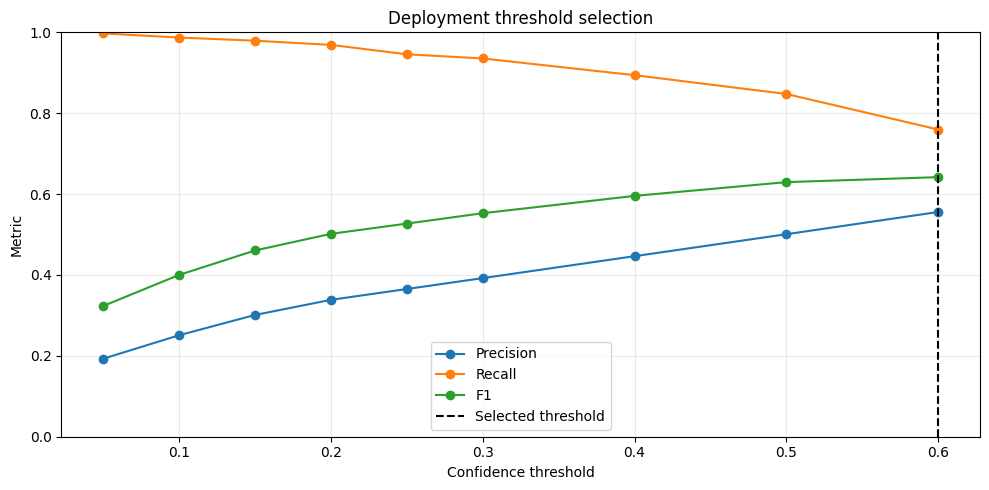

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_dataframe["threshold"],
    threshold_dataframe["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    threshold_dataframe["threshold"],
    threshold_dataframe["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_dataframe["threshold"],
    threshold_dataframe["f1"],
    marker="o",
    label="F1",
)

plt.axvline(
    BEST_CONFIDENCE_THRESHOLD,
    color="black",
    linestyle="--",
    label=(
        "Selected threshold"
    ),
)

plt.xlabel("Confidence threshold")
plt.ylabel("Metric")
plt.ylim(0, 1)
plt.title("Deployment threshold selection")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Per-class and Failure Analysis

**Per-class metrics**

In [30]:
final_evaluation = evaluate_threshold(
    confidence_threshold=(BEST_CONFIDENCE_THRESHOLD),
    iou_threshold=0.50,
)

per_class_rows = []
for class_id, statistics in (final_evaluation["per_class"].items()):
    tp = statistics["tp"]
    fp = statistics["fp"]
    fn = statistics["fn"]
    
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1_score = safe_divide(2 * precision * recall, precision + recall)
    
    per_class_rows.append({
        "class_id": class_id,
        "class_name": model.names[class_id],
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1_score,
    })

per_class_dataframe = pd.DataFrame(per_class_rows)
display(per_class_dataframe.round(4))

,class_id,class_name,tp,fp,fn,precision,recall,f1
0,0,D00,168,120,52,0.5833,0.7636,0.6614
1,1,D10,60,57,27,0.5128,0.6897,0.5882
2,2,D20,51,47,12,0.5204,0.8095,0.6335
3,3,D40,15,11,2,0.5769,0.8824,0.6977


In [31]:
per_class_dataframe.to_csv(
    OUTPUT_ROOT
    / "per_class_operating_metrics.csv",
    index=False,
)

**Failure category counts**